# ToF-SIMS Breast Cancer Comprehensive Analysis
## Multi-Tissue Analysis: Breast Tissue (Primary), Blood Serum, Liver, and Fur

**Study Design:**
- Primary tissue: Breast tissue (Cancer: 97, Control: 95)
- Supporting tissues: Blood serum (48), Liver (40), Fur (61)
- 115 mass features
- No imputation - tissue-specific missing values are biologically meaningful

---

## 0. Setup and Dependencies

In [39]:
# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path

# Statistical analysis
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import mixedlm

# Machine learning
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import (
    cross_val_score, cross_val_predict, LeaveOneGroupOut, 
    StratifiedKFold, permutation_test_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score
)
from sklearn.feature_selection import SelectKBest, f_classif

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All packages loaded successfully!")

All packages loaded successfully!


---
# Phase 1: Data Loading and Exploration

## 1.1 Load Data

In [40]:
# Load the data
data_path = 'Area.txt'
df_raw = pd.read_csv(data_path, sep='\t')

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumns: {df_raw.columns.tolist()[:10]}...")  # First 10 columns
df_raw.head()

Dataset shape: (341, 115)

Columns: ['Index', 'Tissue', 'Mouse', 'Spot', 'Group', '1', '14', '15', '18', '23']...


,Index,Tissue,Mouse,Spot,Group,1,14,15,18,23,...,153,155,157,165,166,171,175,181,197,199
0,blood serum_CC-10a_1,Blood serum,10a,1,Cancer,0.017036,0.020410,0.075120,0.021052,10.137657,...,0.0,0.000000,0.000000,0.000000,0.00000,NaN,NaN,0.264567,0.000000,0.000000
1,blood serum_CC-10a_2,Blood serum,10a,2,Cancer,0.138370,0.066536,0.120410,0.000000,13.052256,...,0.0,0.000000,0.000000,0.000000,0.00000,NaN,NaN,0.000000,0.000000,0.000000
2,blood serum_CC-10a_3,Blood serum,10a,3,Cancer,0.040041,0.029006,0.080154,0.024633,8.416563,...,0.0,0.260005,0.269727,0.338857,0.00000,NaN,NaN,0.319597,0.332987,0.236744
3,blood serum_CC-10a_4,Blood serum,10a,4,Cancer,0.026599,0.039454,0.108881,0.038313,10.206332,...,0.0,0.000000,0.000000,0.000000,0.00000,NaN,NaN,0.000000,0.000000,0.000000
4,blood serum_CC-2a_1,Blood serum,2a,1,Cancer,0.025730,0.029958,0.086167,0.025432,11.792830,...,0.0,0.527825,0.424618,0.529648,0.28002,NaN,NaN,0.321629,0.558074,0.460918


In [41]:
# Separate metadata and mass features
metadata_cols = ['Index', 'Tissue', 'Mouse', 'Spot', 'Group']
mass_cols = [col for col in df_raw.columns if col not in metadata_cols]

metadata = df_raw[metadata_cols].copy()
mass_data = df_raw[mass_cols].copy()

print(f"Number of mass features: {len(mass_cols)}")
print(f"Number of samples: {len(df_raw)}")
print(f"\nMetadata columns: {metadata_cols}")

Number of mass features: 110
Number of samples: 341

Metadata columns: ['Index', 'Tissue', 'Mouse', 'Spot', 'Group']


## 1.2 Data Overview

In [42]:
# Sample distribution across tissues and groups
tissue_group_summary = pd.crosstab(
    metadata['Tissue'], 
    metadata['Group'], 
    margins=True, 
    margins_name='Total'
)

print("Sample Distribution Across Tissues and Groups:")
print(tissue_group_summary)
print("\n" + "="*60)

Sample Distribution Across Tissues and Groups:
Group          Cancer  Control  Total
Tissue                               
Blood serum        32       16     48
Breast tissue      97       95    192
Fur                31       30     61
Liver tissue       24       16     40
Total             184      157    341



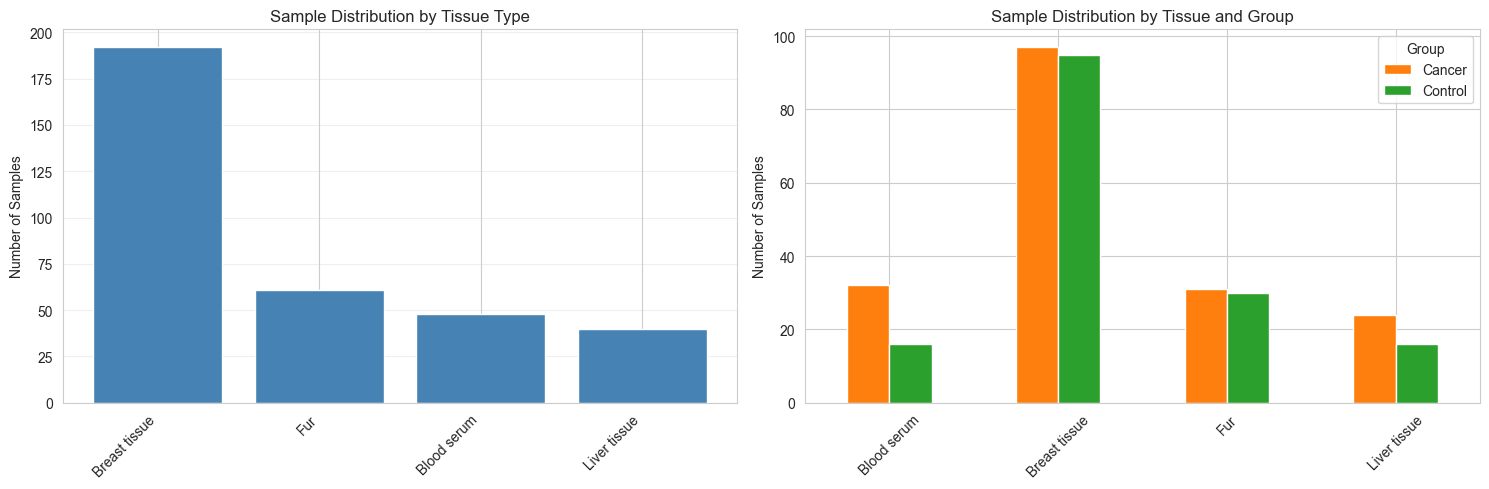

In [43]:
# Visualize sample distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By tissue
tissue_counts = metadata['Tissue'].value_counts()
axes[0].bar(range(len(tissue_counts)), tissue_counts.values, color='steelblue')
axes[0].set_xticks(range(len(tissue_counts)))
axes[0].set_xticklabels(tissue_counts.index, rotation=45, ha='right')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Sample Distribution by Tissue Type')
axes[0].grid(axis='y', alpha=0.3)

# By tissue and group
tissue_group_df = metadata.groupby(['Tissue', 'Group']).size().reset_index(name='Count')
pivot_data = tissue_group_df.pivot(index='Tissue', columns='Group', values='Count')
pivot_data.plot(kind='bar', ax=axes[1], color=['#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Sample Distribution by Tissue and Group')
axes[1].set_xlabel('')
axes[1].legend(title='Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 1.3 Missing Value Analysis (Tissue-Specific)

In [44]:
# Calculate missing values per tissue
def analyze_missing_by_tissue(data, metadata):
    """
    Analyze missing value patterns across different tissues.
    Missing values are biologically meaningful (tissue-specific expression).
    """
    tissues = metadata['Tissue'].unique()
    missing_summary = {}
    
    for tissue in tissues:
        tissue_mask = metadata['Tissue'] == tissue
        tissue_data = data[tissue_mask]
        
        # Count zeros (non-detects) as missing
        missing_pct = (tissue_data == 0).sum() / len(tissue_data) * 100
        detection_pct = 100 - missing_pct
        
        missing_summary[tissue] = {
            'n_samples': len(tissue_data),
            'detection_rate': detection_pct.mean(),
            'min_detection': detection_pct.min(),
            'max_detection': detection_pct.max()
        }
    
    return pd.DataFrame(missing_summary).T

missing_analysis = analyze_missing_by_tissue(mass_data, metadata)
print("Detection Rate Summary by Tissue (%):\n")
print(missing_analysis.round(2))

Detection Rate Summary by Tissue (%):

               n_samples  detection_rate  min_detection  max_detection
Blood serum         48.0           77.29           2.08          100.0
Breast tissue      192.0           79.37           0.52          100.0
Fur                 61.0           75.25           1.64          100.0
Liver tissue        40.0           93.14           2.50          100.0


In [45]:
# Identify tissue-specific masses
def identify_tissue_specific_masses(data, metadata, detection_threshold=0.8):
    """
    Identify masses that are predominantly detected in specific tissues.
    
    Parameters:
    - detection_threshold: minimum detection rate to consider a mass present (default 80%)
    """
    tissues = metadata['Tissue'].unique()
    tissue_specific = {}
    
    for tissue in tissues:
        tissue_mask = metadata['Tissue'] == tissue
        tissue_data = data[tissue_mask]
        
        # Detection rate per mass in this tissue
        detection_rate = (tissue_data > 0).sum() / len(tissue_data)
        
        # Masses well-detected in this tissue
        well_detected = detection_rate[detection_rate >= detection_threshold]
        tissue_specific[tissue] = well_detected.index.tolist()
    
    return tissue_specific

tissue_specific_masses = identify_tissue_specific_masses(mass_data, metadata)

print("Number of Well-Detected Masses per Tissue (>80% detection):\n")
for tissue, masses in tissue_specific_masses.items():
    print(f"{tissue}: {len(masses)} masses")

Number of Well-Detected Masses per Tissue (>80% detection):

Blood serum: 60 masses
Breast tissue: 69 masses
Fur: 38 masses
Liver tissue: 84 masses


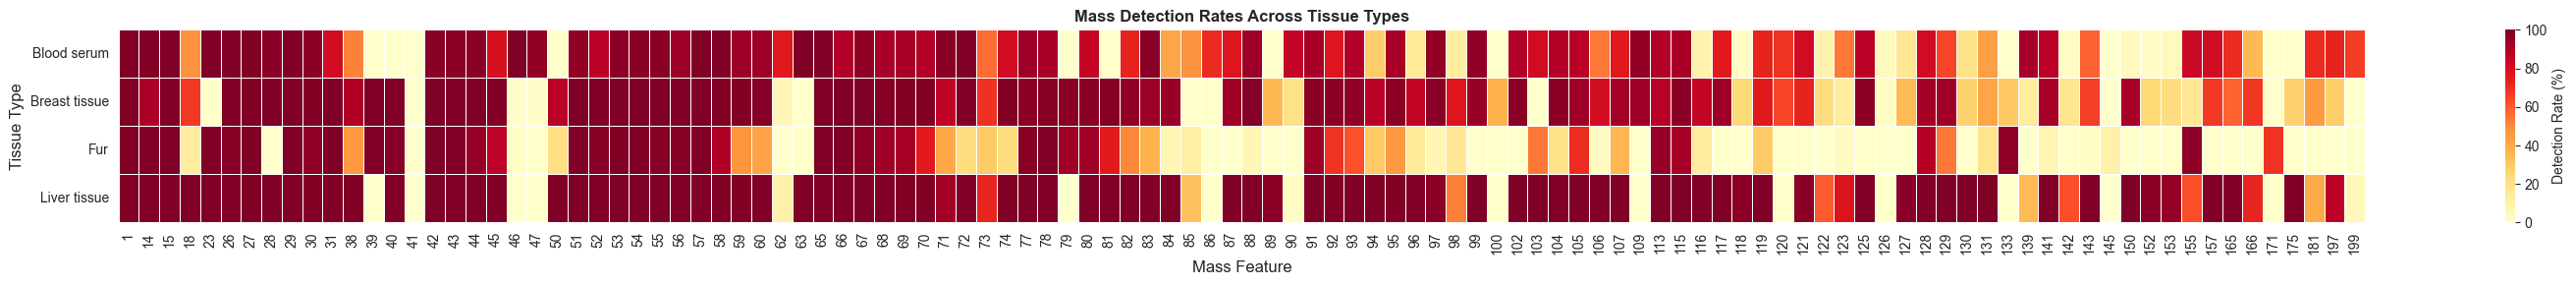


Note: High detection (red) indicates tissue-specific or ubiquitous masses.
Low detection (yellow/white) indicates tissue-absent or rare masses.


In [46]:
# Visualize tissue-specific detection patterns
detection_matrix = pd.DataFrame()

for tissue in metadata['Tissue'].unique():
    tissue_mask = metadata['Tissue'] == tissue
    tissue_data = mass_data[tissue_mask]
    detection_rate = (tissue_data > 0).sum() / len(tissue_data) * 100
    detection_matrix[tissue] = detection_rate

# Plot heatmap
plt.figure(figsize=(30, 3))
sns.heatmap(
    detection_matrix.T, 
    cmap='YlOrRd', 
    cbar_kws={'label': 'Detection Rate (%)'}, 
    vmin=0, 
    vmax=100,
    linewidths=0.5
)
plt.title('Mass Detection Rates Across Tissue Types', fontsize=12, fontweight='bold')
plt.xlabel('Mass Feature', fontsize=12)
plt.ylabel('Tissue Type', fontsize=12)
plt.tight_layout()
plt.show()

print("\nNote: High detection (red) indicates tissue-specific or ubiquitous masses.")
print("Low detection (yellow/white) indicates tissue-absent or rare masses.")

## 1.4 Technical Replicate Assessment

In [47]:
# Check spot-to-spot reproducibility within mice
def calculate_within_mouse_cv(data, metadata):
    """
    Calculate coefficient of variation (CV) for spots within same mouse.
    Lower CV indicates better technical reproducibility.
    """
    cv_results = []
    
    for tissue in metadata['Tissue'].unique():
        tissue_mask = metadata['Tissue'] == tissue
        tissue_meta = metadata[tissue_mask]
        tissue_data = data[tissue_mask]
        
        for mouse in tissue_meta['Mouse'].unique():
            mouse_mask = tissue_meta['Mouse'] == mouse
            mouse_data = tissue_data[mouse_mask.values]
            
            if len(mouse_data) > 1:  # Need at least 2 spots
                # Replace zeros with NaN for CV calculation
                mouse_data_clean = mouse_data.replace(0, np.nan)
                
                mean_vals = mouse_data_clean.mean()
                std_vals = mouse_data_clean.std()
                cv = (std_vals / mean_vals * 100).dropna()
                
                cv_results.append({
                    'Tissue': tissue,
                    'Mouse': mouse,
                    'Median_CV': cv.median(),
                    'Mean_CV': cv.mean(),
                    'N_spots': len(mouse_data)
                })
    
    return pd.DataFrame(cv_results)

cv_analysis = calculate_within_mouse_cv(mass_data, metadata)

print("Technical Reproducibility (Within-Mouse CV%):\n")
print(cv_analysis.groupby('Tissue')[['Median_CV', 'Mean_CV']].agg(['mean', 'std']).round(2))

Technical Reproducibility (Within-Mouse CV%):

              Median_CV        Mean_CV       
                   mean    std    mean    std
Tissue                                       
Blood serum       33.16  20.07   35.95  18.59
Breast tissue     21.19   6.54   24.68   6.69
Fur               16.01   4.08   21.26   4.25
Liver tissue       7.85   4.66   10.31   5.49


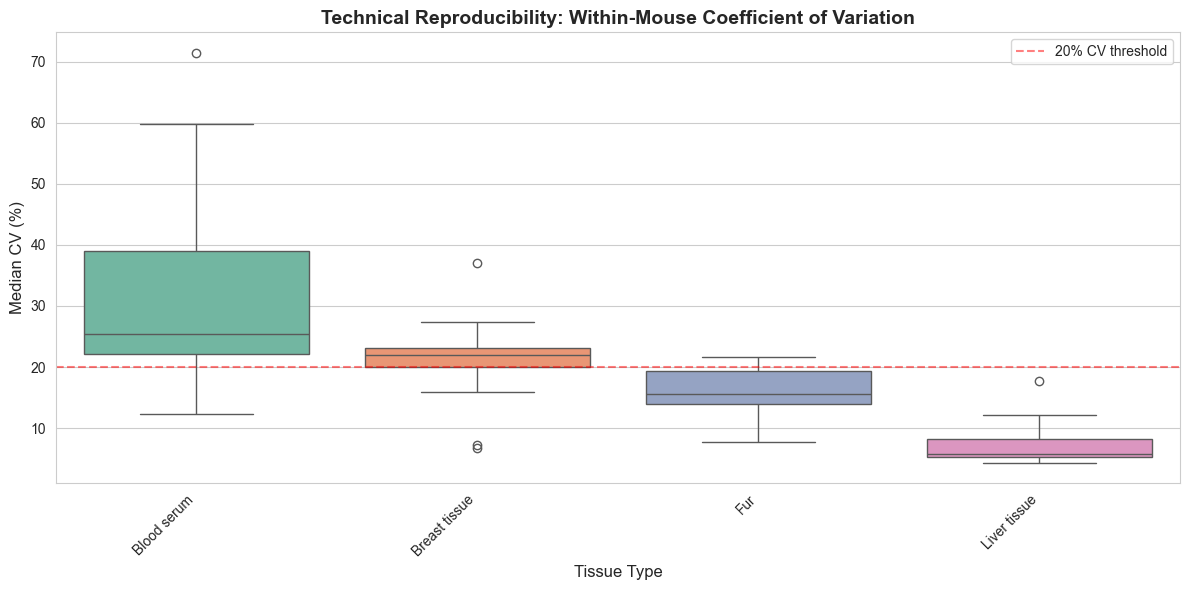


Note: CV < 20% is generally considered good reproducibility for MS data.


In [48]:
# Visualize technical reproducibility
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=cv_analysis, x='Tissue', y='Median_CV', ax=ax, palette='Set2')
ax.set_ylabel('Median CV (%)', fontsize=12)
ax.set_xlabel('Tissue Type', fontsize=12)
ax.set_title('Technical Reproducibility: Within-Mouse Coefficient of Variation', 
             fontsize=14, fontweight='bold')
ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='20% CV threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nNote: CV < 20% is generally considered good reproducibility for MS data.")

---
# Phase 2: Data Preprocessing

## 2.1 Create Tissue-Specific Datasets

In [49]:
def prepare_tissue_dataset(tissue_name, data, metadata, min_detection_rate=0.2):
    """
    Prepare tissue-specific dataset with appropriate filtering.
    
    Parameters:
    - tissue_name: Name of tissue to extract
    - data: Mass feature data
    - metadata: Sample metadata
    - min_detection_rate: Minimum detection rate to keep a mass (default 20%)
    
    Returns:
    - Dictionary with cleaned data, metadata, and feature names
    """
    # Filter for specific tissue
    tissue_mask = metadata['Tissue'] == tissue_name
    tissue_meta = metadata[tissue_mask].copy()
    tissue_data = data[tissue_mask].copy()
    
    # Remove masses with low detection rate in this tissue
    detection_rate = (tissue_data > 0).sum() / len(tissue_data)
    valid_masses = detection_rate[detection_rate >= min_detection_rate].index
    tissue_data = tissue_data[valid_masses]
    
    # Encode group labels
    tissue_meta['Group_encoded'] = (tissue_meta['Group'] == 'Cancer').astype(int)
    
    print(f"\n{tissue_name}:")
    print(f"  Samples: {len(tissue_data)}")
    print(f"  Cancer: {(tissue_meta['Group'] == 'Cancer').sum()}")
    print(f"  Control: {(tissue_meta['Group'] == 'Control').sum()}")
    print(f"  Features retained: {len(valid_masses)}/{len(data.columns)}")
    
    return {
        'data': tissue_data,
        'metadata': tissue_meta,
        'features': valid_masses.tolist(),
        'name': tissue_name
    }

# Create datasets for each tissue
print("Preparing Tissue-Specific Datasets...")
print("="*60)

breast_data = prepare_tissue_dataset('Breast tissue', mass_data, metadata)
serum_data = prepare_tissue_dataset('Blood serum', mass_data, metadata)
liver_data = prepare_tissue_dataset('Liver tissue', mass_data, metadata)
fur_data = prepare_tissue_dataset('Fur', mass_data, metadata)

print("\n" + "="*60)
print("Dataset preparation complete!")

Preparing Tissue-Specific Datasets...

Breast tissue:
  Samples: 192
  Cancer: 97
  Control: 95
  Features retained: 92/110

Blood serum:
  Samples: 48
  Cancer: 32
  Control: 16
  Features retained: 86/110

Liver tissue:
  Samples: 40
  Cancer: 24
  Control: 16
  Features retained: 94/110

Fur:
  Samples: 61
  Cancer: 31
  Control: 30
  Features retained: 60/110

Dataset preparation complete!


## 2.2 Normalization and Transformation

In [50]:
def normalize_and_transform(data, method='log', scaling='pareto'):
    """
    Apply normalization and scaling transformations.
    
    Parameters:
    - data: Raw mass feature data
    - method: Transformation method ('log', 'sqrt', or 'none')
    - scaling: Scaling method ('pareto', 'auto', 'robust', or 'none')
    
    Returns:
    - Transformed and scaled data
    """
    data_transformed = data.copy()
    
    # Replace zeros with small value for log transformation
    if method == 'log':
        data_transformed = data_transformed.replace(0, np.nan)
        min_nonzero = data_transformed.min().min()
        data_transformed = data_transformed.fillna(min_nonzero / 2)
        data_transformed = np.log2(data_transformed + 1)
    elif method == 'sqrt':
        data_transformed = np.sqrt(data_transformed)
    
    # Apply scaling
    if scaling == 'pareto':
        # Pareto scaling: mean-center and divide by sqrt(std)
        mean = data_transformed.mean()
        std = data_transformed.std()
        data_scaled = (data_transformed - mean) / np.sqrt(std)
    elif scaling == 'auto':
        scaler = StandardScaler()
        data_scaled = pd.DataFrame(
            scaler.fit_transform(data_transformed),
            columns=data_transformed.columns,
            index=data_transformed.index
        )
    elif scaling == 'robust':
        scaler = RobustScaler()
        data_scaled = pd.DataFrame(
            scaler.fit_transform(data_transformed),
            columns=data_transformed.columns,
            index=data_transformed.index
        )
    else:
        data_scaled = data_transformed
    
    return data_scaled

# Apply to all tissue datasets
print("Applying log transformation and Pareto scaling...\n")

breast_data['data_processed'] = normalize_and_transform(breast_data['data'])
serum_data['data_processed'] = normalize_and_transform(serum_data['data'])
liver_data['data_processed'] = normalize_and_transform(liver_data['data'])
fur_data['data_processed'] = normalize_and_transform(fur_data['data'])

print("Preprocessing complete!")

Applying log transformation and Pareto scaling...

Preprocessing complete!


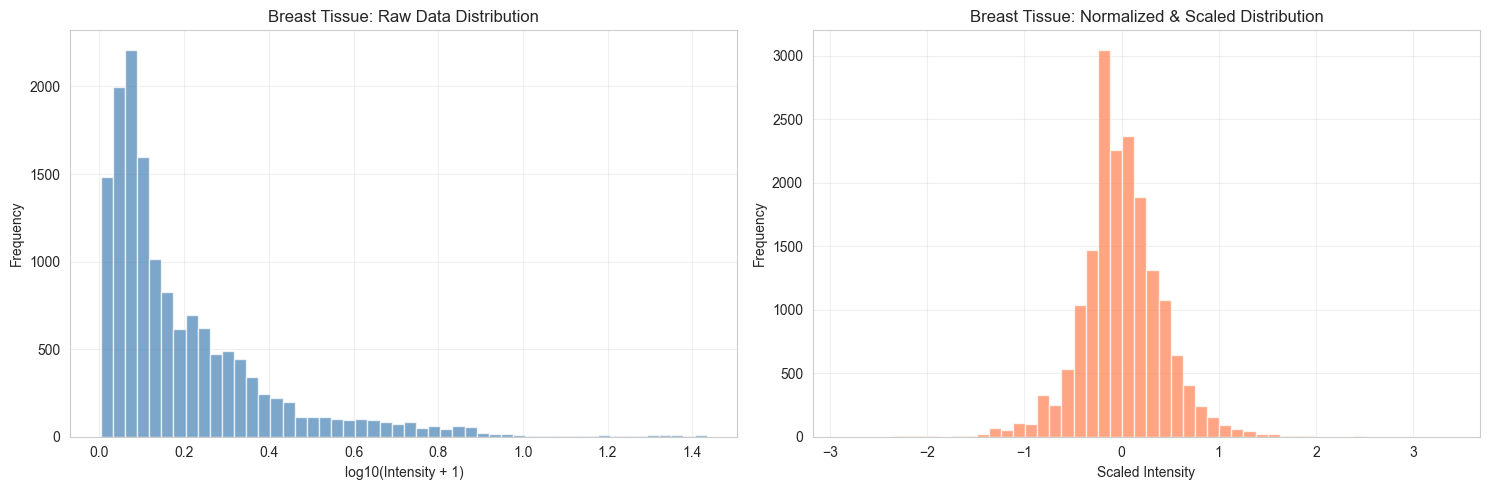

In [51]:
# Visualize normalization effect
def plot_normalization_effect(raw_data, processed_data, tissue_name):
    """
    Compare distributions before and after normalization.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Raw data (log scale for visualization)
    raw_nonzero = raw_data.replace(0, np.nan).values.flatten()
    raw_nonzero = raw_nonzero[~np.isnan(raw_nonzero)]
    axes[0].hist(np.log10(raw_nonzero + 1), bins=50, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('log10(Intensity + 1)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'{tissue_name}: Raw Data Distribution')
    axes[0].grid(alpha=0.3)
    
    # Processed data
    processed_flat = processed_data.values.flatten()
    processed_flat = processed_flat[~np.isnan(processed_flat)]
    axes[1].hist(processed_flat, bins=50, color='coral', alpha=0.7)
    axes[1].set_xlabel('Scaled Intensity')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{tissue_name}: Normalized & Scaled Distribution')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Show for breast tissue
plot_normalization_effect(breast_data['data'], breast_data['data_processed'], 'Breast Tissue')

---
# Phase 3: Breast Tissue Analysis (PRIMARY)

## 3.1 Univariate Statistical Analysis

In [52]:
def univariate_analysis(data_processed, data_raw, metadata, alpha=0.05):
    """
    Perform comprehensive univariate analysis for each mass feature.

    Parameters:
    -----------
    data_processed : DataFrame
        Normalized and scaled data (for statistical tests)
    data_raw : DataFrame
        Raw intensity data (for fold change calculation)
    metadata : DataFrame
        Sample metadata with 'Group' column
    alpha : float
        Significance threshold for FDR

    Returns:
    --------
    DataFrame with statistics for each feature:
    - p-values (t-test and Mann-Whitney)
    - Fold change (calculated on raw data)
    - Cohen's d (effect size)
    - FDR-corrected p-values
    """
    cancer_mask = metadata['Group'] == 'Cancer'
    control_mask = metadata['Group'] == 'Control'

    results = []

    for feature in data_processed.columns:
        # Use processed data for statistical tests
        cancer_vals_proc = data_processed.loc[cancer_mask, feature].dropna()
        control_vals_proc = data_processed.loc[control_mask, feature].dropna()

        # Use raw data for fold change calculation
        if feature in data_raw.columns:
            cancer_vals_raw = data_raw.loc[cancer_mask, feature]
            control_vals_raw = data_raw.loc[control_mask, feature]

            # For fold change, exclude zeros and take mean of detected values
            cancer_detected = cancer_vals_raw[cancer_vals_raw > 0]
            control_detected = control_vals_raw[control_vals_raw > 0]
        else:
            cancer_detected = pd.Series([])
            control_detected = pd.Series([])

        # Skip if insufficient data
        if len(cancer_vals_proc) < 3 or len(control_vals_proc) < 3:
            continue

        # T-test on processed data
        t_stat, t_pval = ttest_ind(cancer_vals_proc, control_vals_proc, equal_var=False)

        # Mann-Whitney U test on processed data
        u_stat, u_pval = mannwhitneyu(cancer_vals_proc, control_vals_proc, alternative='two-sided')

        # Effect size (Cohen's d) on processed data
        mean_cancer_proc = cancer_vals_proc.mean()
        mean_control_proc = control_vals_proc.mean()
        pooled_std = np.sqrt(((len(cancer_vals_proc)-1)*cancer_vals_proc.std()**2 +
                               (len(control_vals_proc)-1)*control_vals_proc.std()**2) /
                              (len(cancer_vals_proc) + len(control_vals_proc) - 2))
        cohens_d = (mean_cancer_proc - mean_control_proc) / pooled_std if pooled_std > 0 else 0

        # Fold change on RAW data (only detected values)
        if len(cancer_detected) > 0 and len(control_detected) > 0:
            mean_cancer_raw = cancer_detected.mean()
            mean_control_raw = control_detected.mean()

            fc = mean_cancer_raw / mean_control_raw if mean_control_raw > 0 else np.nan
            log2_fc = np.log2(fc) if not np.isnan(fc) and fc > 0 else np.nan
        else:
            mean_cancer_raw = np.nan
            mean_control_raw = np.nan
            fc = np.nan
            log2_fc = np.nan

        # Detection rates
        cancer_detection = (cancer_vals_raw > 0).sum() / len(cancer_vals_raw) * 100 if feature in data_raw.columns else np.nan
        control_detection = (control_vals_raw > 0).sum() / len(control_vals_raw) * 100 if feature in data_raw.columns else np.nan

        results.append({
            'Feature': feature,
            'Mean_Cancer_Raw': mean_cancer_raw,
            'Mean_Control_Raw': mean_control_raw,
            'Mean_Cancer_Normalized': mean_cancer_proc,
            'Mean_Control_Normalized': mean_control_proc,
            'Fold_Change': fc,
            'Log2_FC': log2_fc,
            'T_test_pval': t_pval,
            'Mann_Whitney_pval': u_pval,
            'Cohens_d': cohens_d,
            'Cancer_Detection_%': cancer_detection,
            'Control_Detection_%': control_detection,
            'N_Cancer': len(cancer_vals_proc),
            'N_Control': len(control_vals_proc)
        })

    results_df = pd.DataFrame(results)

    # FDR correction
    results_df['FDR_ttest'] = multipletests(results_df['T_test_pval'], method='fdr_bh')[1]
    results_df['FDR_mannwhitney'] = multipletests(results_df['Mann_Whitney_pval'], method='fdr_bh')[1]

    # Significance flags
    results_df['Significant_FDR'] = (results_df['FDR_ttest'] < alpha) | (results_df['FDR_mannwhitney'] < alpha)

    # Sort by significance
    results_df = results_df.sort_values('T_test_pval')

    return results_df

# Perform analysis on breast tissue
print("Performing univariate analysis on Breast Tissue...\n")
breast_univariate = univariate_analysis(breast_data['data_processed'],breast_data['data'], breast_data['metadata'])

# Summary statistics
n_significant = breast_univariate['Significant_FDR'].sum()
print(f"Significant features (FDR < 0.05): {n_significant} / {len(breast_univariate)}")
print(f"\nTop 10 most significant masses:")
print(breast_univariate[['Feature', 'Log2_FC', 'Cohens_d', 'T_test_pval', 'FDR_ttest']].head(10))

Performing univariate analysis on Breast Tissue...

Significant features (FDR < 0.05): 87 / 92

Top 10 most significant masses:
   Feature   Log2_FC  Cohens_d   T_test_pval     FDR_ttest
12      40 -0.577288 -3.385563  6.990257e-58  6.431037e-56
29      66 -0.770387 -3.036920  4.559049e-51  2.097163e-49
19      52 -0.575299 -3.100669  2.336082e-48  7.163984e-47
11      39  1.675259  2.975848  2.060646e-47  4.739486e-46
5       27 -0.531039 -2.649706  5.826288e-44  1.072037e-42
7       29 -0.592677 -2.588566  1.848496e-41  2.834361e-40
21      54 -1.156240 -2.581300  9.235798e-41  1.213848e-39
20      53 -0.407645 -2.394980  1.238528e-38  1.424308e-37
28      65 -0.431043 -2.333763  1.481963e-37  1.514895e-36
30      67 -0.977479 -2.417380  2.136762e-36  1.965821e-35


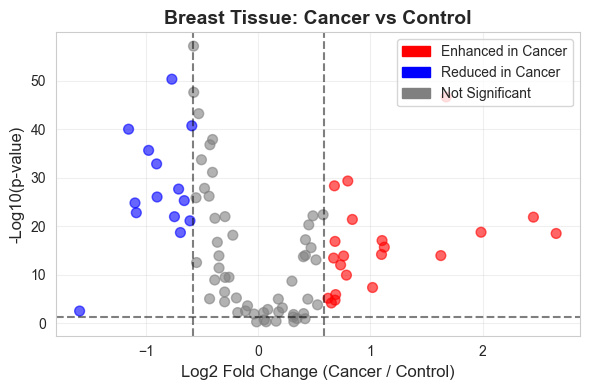

In [53]:
# Volcano plot
def plot_volcano(results_df, fc_threshold=1.5, pval_threshold=0.05, title='Volcano Plot'):
    """
    Create volcano plot showing fold change vs significance.
    """
    plt.figure(figsize=(6, 4))
    
    # Calculate -log10(p-value)
    results_df['neg_log10_pval'] = -np.log10(results_df['T_test_pval'])
    
    # Color code points
    colors = []
    for idx, row in results_df.iterrows():
        if row['FDR_ttest'] < pval_threshold and abs(row['Log2_FC']) >= np.log2(fc_threshold):
            if row['Log2_FC'] > 0:
                colors.append('red')  # Upregulated in cancer
            else:
                colors.append('blue')  # Downregulated in cancer
        else:
            colors.append('gray')  # Not significant
    
    # Scatter plot
    plt.scatter(results_df['Log2_FC'], results_df['neg_log10_pval'], 
                c=colors, alpha=0.6, s=50)
    
    # Threshold lines
    plt.axhline(y=-np.log10(pval_threshold), color='black', linestyle='--', alpha=0.5, label='p = 0.05')
    plt.axvline(x=np.log2(fc_threshold), color='black', linestyle='--', alpha=0.5)
    plt.axvline(x=-np.log2(fc_threshold), color='black', linestyle='--', alpha=0.5)
    
    plt.xlabel('Log2 Fold Change (Cancer / Control)', fontsize=12)
    plt.ylabel('-Log10(p-value)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    
    # Legend
    up_patch = mpatches.Patch(color='red', label='Enhanced in Cancer')
    down_patch = mpatches.Patch(color='blue', label='Reduced in Cancer')
    ns_patch = mpatches.Patch(color='gray', label='Not Significant')
    plt.legend(handles=[up_patch, down_patch, ns_patch], loc='upper right')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_volcano(breast_univariate, title='Breast Tissue: Cancer vs Control')

Plotting 20 features with |Log2_FC| >= 0.77 and p-value < 0.05


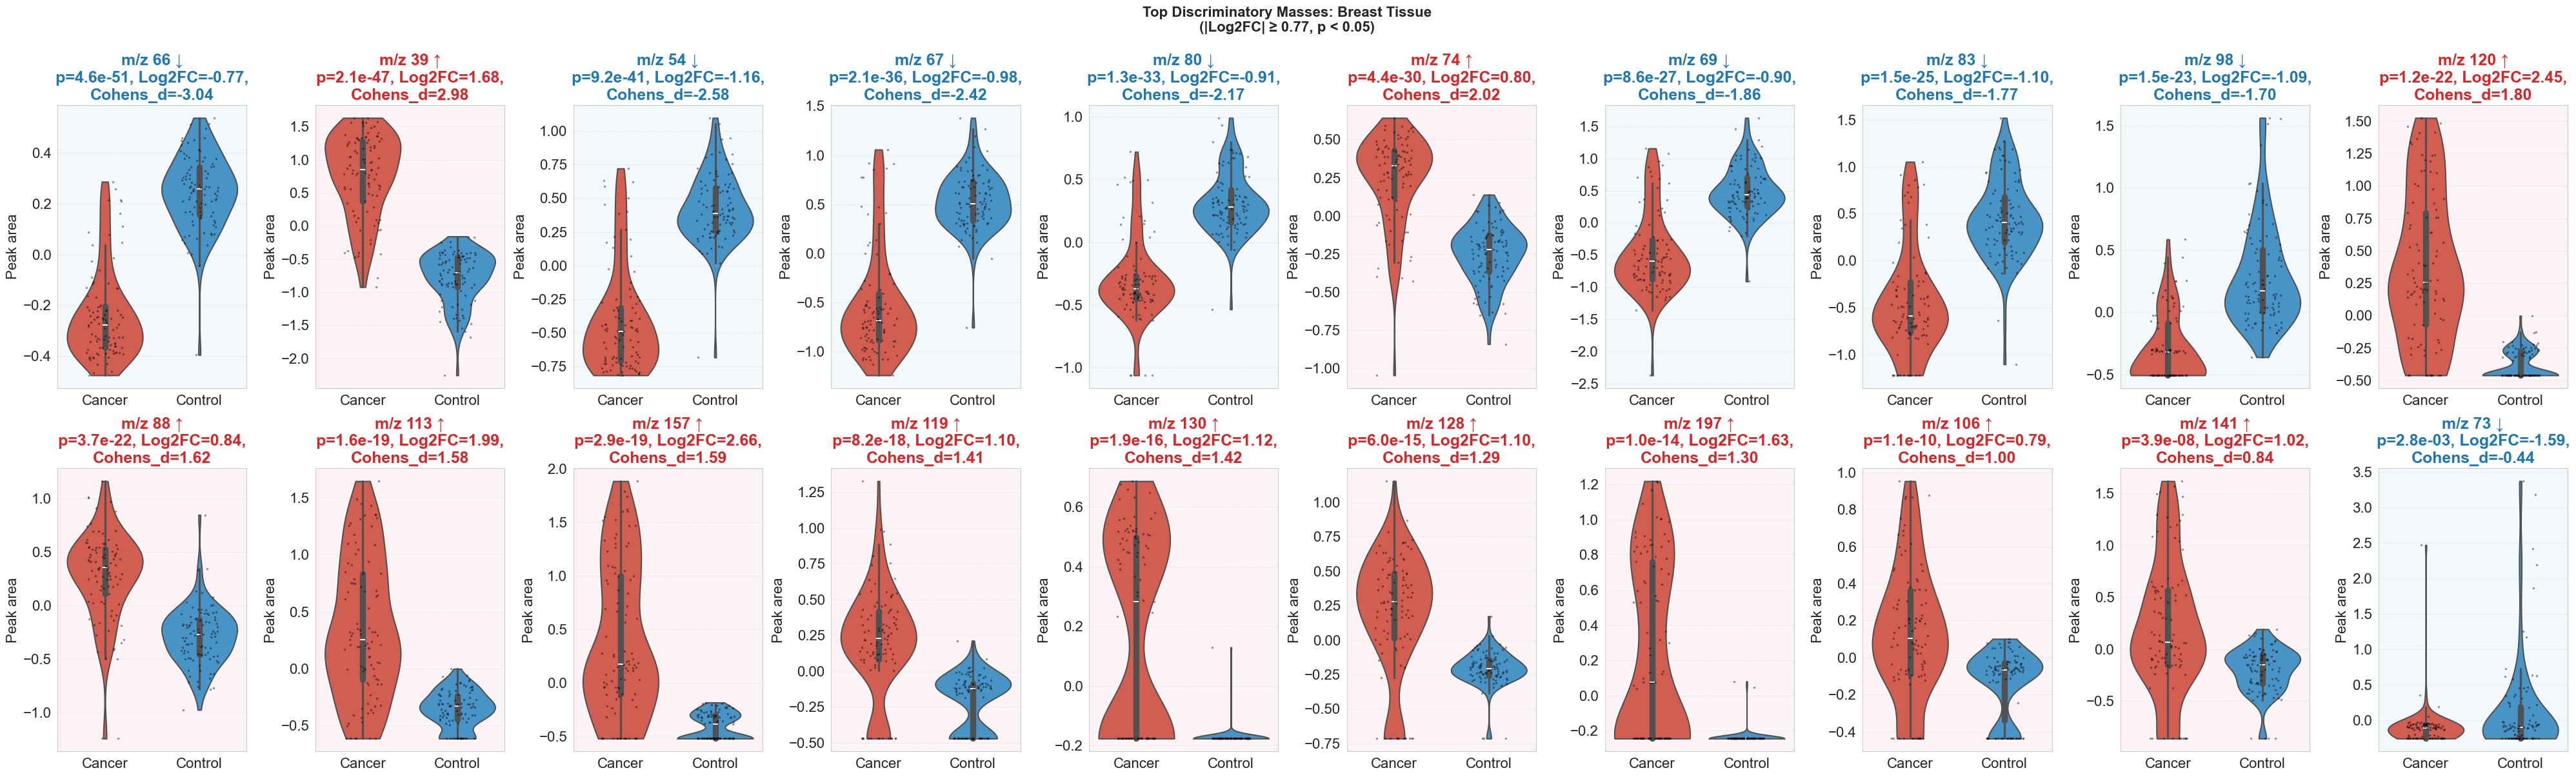

In [54]:
# Violin plots for top discriminatory features
def plot_top_features_violinplots(data, metadata, results_df, n_features=10, 
                                   min_log2fc=0.5, max_pval=0.05):
    """
    Create violin plots for top significant features.
    
    Parameters:
    -----------
    data : DataFrame
        Feature data (processed)
    metadata : DataFrame
        Sample metadata
    results_df : DataFrame
        Statistical results with T_test_pval and Log2_FC
    n_features : int
        Maximum number of features to plot
    min_log2fc : float
        Minimum absolute log2 fold change threshold (default: 0.5 = 1.4x fold change)
    max_pval : float
        Maximum p-value threshold (default: 0.05)
    """
    # Filter by both p-value AND fold change
    # Remove NaN values in Log2_FC first
    filtered_df = results_df.dropna(subset=['Log2_FC'])
    
    # Apply filters: significant p-value AND meaningful fold change
    significant_features = filtered_df[
        (filtered_df['T_test_pval'] < max_pval) & 
        (abs(filtered_df['Log2_FC']) >= min_log2fc)
    ].copy()
    
    # Sort by p-value to get most significant
    significant_features = significant_features.sort_values('T_test_pval')
    
    # Take top n features
    top_features = significant_features.head(n_features)['Feature'].tolist()
    
    if len(top_features) == 0:
        print(f"No features found with |Log2_FC| >= {min_log2fc} and p-value < {max_pval}")
        print(f"Try relaxing the thresholds.")
        return
    
    print(f"Plotting {len(top_features)} features with |Log2_FC| >= {min_log2fc} and p-value < {max_pval}")
    
    n_cols = n_features // 2
    n_rows = int(np.ceil(len(top_features) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 6*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_features):
        feature_data = pd.DataFrame({
            'Intensity': data[feature],
            'Group': metadata['Group'].values
        })
        
        # Violin plot with better styling
        sns.violinplot(
            data=feature_data, 
            x='Group', 
            y='Intensity', 
            ax=axes[idx], 
            palette={'Cancer': '#e74c3c', 'Control': '#3498db'},
            inner='box',  # Shows quartiles inside
            cut=0,  # Limits the violin to data range
            linewidth=1.5
        )
        
        # Add individual points with jitter
        sns.stripplot(
            data=feature_data, 
            x='Group', 
            y='Intensity', 
            ax=axes[idx], 
            color='black', 
            alpha=0.4, 
            size=2.5,
            jitter=0.2
        )
        
        # Get statistics
        stats = significant_features[significant_features['Feature'] == feature].iloc[0]
        
        # Determine up/down regulation and set colors
        if stats['Log2_FC'] > 0:
            regulation = "↑"  # Upregulated in cancer
            title_color = "#d62728"  # Red for upregulation
            arrow_symbol = "▲"
        else:
            regulation = "↓"  # Downregulated in cancer
            title_color = "#1f77b4"  # Blue for downregulation
            arrow_symbol = "▼"
        
        # Title with statistics
        title_text = (f"m/z {feature} {regulation}\n"
                     f"p={stats['T_test_pval']:.1e}, "
                     f"Log2FC={stats['Log2_FC']:.2f},\n"
                     f"Cohens_d={stats['Cohens_d']:.2f}")
        
        axes[idx].set_title(title_text, fontsize=18, fontweight='bold', color=title_color)
        axes[idx].set_xlabel('')
        axes[idx].set_ylabel('Peak area', fontsize=16)
        axes[idx].tick_params(axis='both', labelsize=16)
        axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add colored background patch to highlight direction
        axes[idx].patch.set_facecolor(title_color)
        axes[idx].patch.set_alpha(0.05)
    
    # Hide empty subplots
    for idx in range(len(top_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(
        f'Top Discriminatory Masses: Breast Tissue\n'
        f'(|Log2FC| ≥ {min_log2fc}, p < {max_pval})',
        fontsize=16, fontweight='bold', y=1.00
    )
    plt.tight_layout()
    plt.show()

# Call with fold change cutoff
# min_log2fc=0.5 means 1.4-fold change (2^0.5 = 1.41)
# min_log2fc=1.0 means 2-fold change (2^1.0 = 2.0)
plot_top_features_violinplots(
    breast_data['data_processed'], 
    breast_data['metadata'], 
    breast_univariate,
    n_features=20,
    min_log2fc=0.77,  # 1.4-fold change minimum
    max_pval=0.05    # FDR < 0.05
)

## 3.2 Principal Component Analysis (PCA)

In [55]:
def perform_pca(data, metadata, n_components=5):
    """
    Perform PCA and return scores, loadings, and explained variance.
    """
    # Remove NaN values
    data_clean = data.fillna(0)
    
    # Perform PCA
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    scores = pca.fit_transform(data_clean)
    
    # Create scores dataframe
    scores_df = pd.DataFrame(
        scores,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=data.index
    )
    scores_df['Group'] = metadata['Group'].values
    scores_df['Mouse'] = metadata['Mouse'].values
    
    # Loadings
    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=data.columns
    )
    
    return {
        'model': pca,
        'scores': scores_df,
        'loadings': loadings_df,
        'explained_variance': pca.explained_variance_ratio_
    }

# Perform PCA on breast tissue
print("Performing PCA on Breast Tissue...\n")
breast_pca = perform_pca(breast_data['data_processed'], breast_data['metadata'])

print("Explained variance by component:")
for i, var in enumerate(breast_pca['explained_variance']):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"\nCumulative variance (PC1-PC2): {sum(breast_pca['explained_variance'][:2])*100:.2f}%")

Performing PCA on Breast Tissue...

Explained variance by component:
  PC1: 49.31%
  PC2: 17.17%
  PC3: 8.42%
  PC4: 4.35%
  PC5: 3.48%

Cumulative variance (PC1-PC2): 66.49%


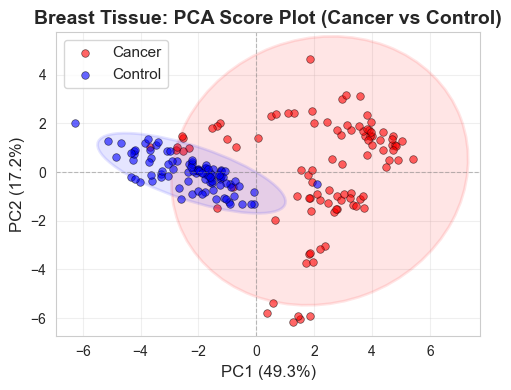

In [56]:
# PCA Score plot
def plot_pca_scores(pca_results, title='PCA Score Plot'):
    """
    Create PCA score plot with confidence ellipses.
    """
    scores_df = pca_results['scores']
    explained_var = pca_results['explained_variance']
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Plot by group
    for group in ['Cancer', 'Control']:
        group_data = scores_df[scores_df['Group'] == group]
        color = 'red' if group == 'Cancer' else 'blue'
        
        ax.scatter(group_data['PC1'], group_data['PC2'], 
                   label=group, alpha=0.6, s=30, color=color, edgecolors='black', linewidth=0.5)
        
        # Add confidence ellipse (95%)
        if len(group_data) > 2:
            mean_x, mean_y = group_data['PC1'].mean(), group_data['PC2'].mean()
            cov = np.cov(group_data['PC1'], group_data['PC2'])
            lambda_, v = np.linalg.eig(cov)
            lambda_ = np.sqrt(lambda_)
            angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
            
            ellipse = Ellipse((mean_x, mean_y), 
                             width=lambda_[0]*2*2.447,  # 95% CI
                             height=lambda_[1]*2*2.447,
                             angle=angle, 
                             facecolor=color, 
                             alpha=0.1, 
                             edgecolor=color, 
                             linewidth=2)
            ax.add_patch(ellipse)
    
    ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_pca_scores(breast_pca, title='Breast Tissue: PCA Score Plot (Cancer vs Control)')

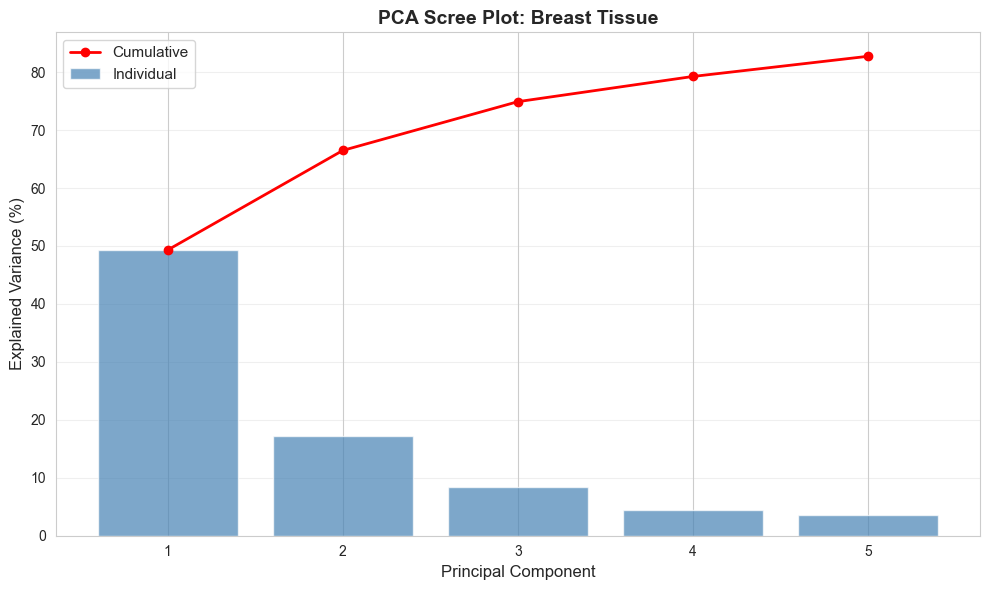

In [57]:
# Scree plot - explained variance
fig, ax = plt.subplots(figsize=(10, 6))
pc_numbers = range(1, len(breast_pca['explained_variance']) + 1)
cumulative_var = np.cumsum(breast_pca['explained_variance']) * 100

ax.bar(pc_numbers, breast_pca['explained_variance'] * 100, alpha=0.7, color='steelblue', label='Individual')
ax.plot(pc_numbers, cumulative_var, marker='o', color='red', linewidth=2, label='Cumulative')

ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance (%)', fontsize=12)
ax.set_title('PCA Scree Plot: Breast Tissue', fontsize=14, fontweight='bold')
ax.set_xticks(pc_numbers)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
#1. View the loadings dataframe:
# Display loadings for PC1 and PC2
print(breast_pca['loadings'][['PC1', 'PC2']])

          PC1       PC2
1   -0.014217  0.004470
14  -0.012268  0.029100
15  -0.026240 -0.012226
18   0.043468 -0.005254
26  -0.027376  0.000253
..        ...       ...
165  0.038118  0.106238
166  0.068603  0.100217
175  0.098473  0.106217
181  0.054175  0.081026
197  0.111383  0.124550

[92 rows x 2 columns]


In [59]:
# 2. Find features with highest loadings (most important):
# Top 10 features contributing to PC1
top_pc1 = breast_pca['loadings']['PC1'].abs().sort_values(ascending=False).head(10)
print("Top 10 features for PC1:")
print(top_pc1)

Top 10 features for PC1:
39     0.304256
69     0.236183
67     0.236025
55     0.230792
83     0.203669
57     0.201560
43     0.191943
54     0.184623
81     0.182179
157    0.177143
Name: PC1, dtype: float64


In [60]:
# Top 10 features contributing to PC2
top_pc2 = breast_pca['loadings']['PC2'].abs().sort_values(ascending=False).head(10)
print("Top 10 features for PC2:")
print(top_pc2)

Top 10 features for PC2:
91     0.226881
105    0.226198
95     0.203251
93     0.196570
157    0.192609
81     0.192504
141    0.187832
107    0.180907
58     0.179219
117    0.171268
Name: PC2, dtype: float64


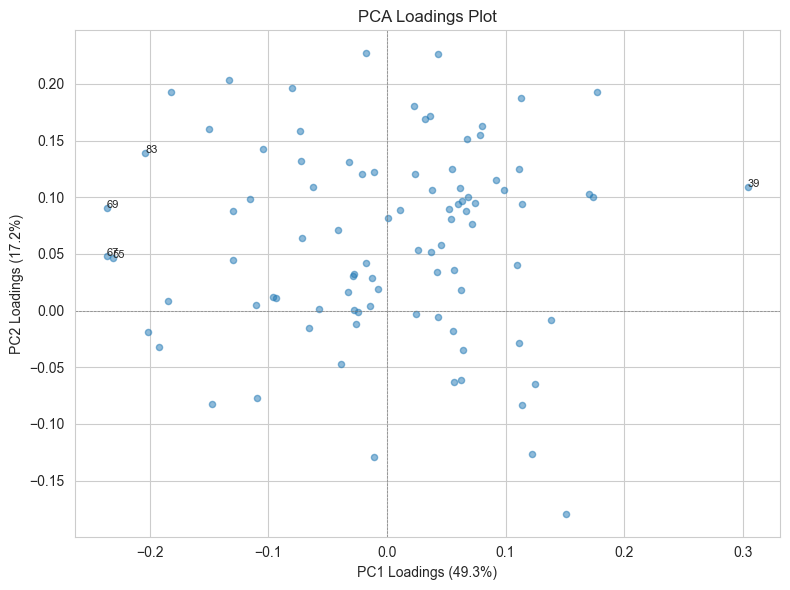

In [61]:
# 3. Create a loadings plot (biplot style):
# Loadings plot for PC1 vs PC2
fig, ax = plt.subplots(figsize=(8, 6))

loadings = breast_pca['loadings']
ax.scatter(loadings['PC1'], loadings['PC2'], alpha=0.5, s=20)

# Optionally label the top features
top_features = loadings['PC1'].abs().sort_values(ascending=False).head(5).index
for feature in top_features:
    ax.annotate(feature, 
                xy=(loadings.loc[feature, 'PC1'], loadings.loc[feature, 'PC2']),
                fontsize=8)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel(f'PC1 Loadings ({breast_pca["explained_variance"][0]*100:.1f}%)')
ax.set_ylabel(f'PC2 Loadings ({breast_pca["explained_variance"][1]*100:.1f}%)')
ax.set_title('PCA Loadings Plot')
plt.tight_layout()
plt.show()


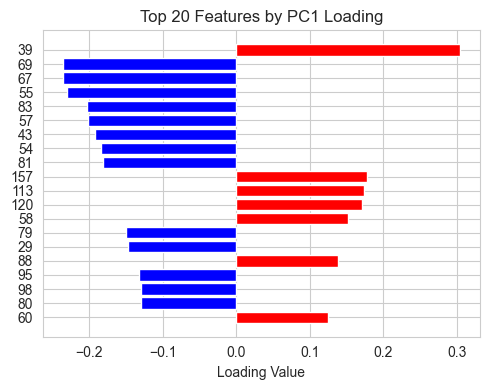

In [62]:
# 4. Create a bar plot for loadings:
# Bar plot of loadings for PC1
top_n = 20
top_loadings = breast_pca['loadings']['PC1'].abs().sort_values(ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['red' if breast_pca['loadings'].loc[f, 'PC1'] > 0 else 'blue' 
          for f in top_loadings.index]

ax.barh(range(len(top_loadings)), 
        [breast_pca['loadings'].loc[f, 'PC1'] for f in top_loadings.index],
        color=colors)
ax.set_yticks(range(len(top_loadings)))
ax.set_yticklabels(top_loadings.index)
ax.set_xlabel('Loading Value')
ax.set_title(f'Top {top_n} Features by PC1 Loading')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3.3 Partial Least Squares Discriminant Analysis (PLS-DA)

In [63]:
def perform_plsda(data, metadata, n_components=5, cv_folds=5):
    """
    Perform PLS-DA with cross-validation.
    
    Returns model, scores, loadings, VIP scores, and CV performance.
    """
    # Prepare data
    X = data.fillna(0).values
    y = (metadata['Group'] == 'Cancer').astype(int).values
    
    # Fit PLS-DA
    plsda = PLSRegression(n_components=n_components, scale=False)
    plsda.fit(X, y)
    
    # Scores
    scores = plsda.transform(X)
    scores_df = pd.DataFrame(
        scores,
        columns=[f'LV{i+1}' for i in range(n_components)],
        index=data.index
    )
    scores_df['Group'] = metadata['Group'].values
    
    # Loadings
    loadings_df = pd.DataFrame(
        plsda.x_loadings_,
        columns=[f'LV{i+1}' for i in range(n_components)],
        index=data.columns
    )
    
    # Calculate VIP scores
    def calculate_vip(model, X_data):
        """
        Calculate Variable Importance in Projection (VIP) scores.
        """
        t = model.x_scores_
        w = model.x_weights_
        q = model.y_loadings_
        
        p, h = w.shape
        vip_scores = np.zeros((p,))
        
        s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
        total_s = np.sum(s)
        
        for i in range(p):
            weight = np.array([(w[i, j] / np.linalg.norm(w[:, j]))**2 for j in range(h)])
            vip_scores[i] = np.sqrt(p * (s.T @ weight) / total_s)
        
        return vip_scores
    
    vip_scores = calculate_vip(plsda, X)
    vip_df = pd.DataFrame({
        'Feature': data.columns,
        'VIP': vip_scores
    }).sort_values('VIP', ascending=False)
    
    # Cross-validation using leave-one-mouse-out
    logo = LeaveOneGroupOut()
    groups = metadata['Mouse'].values
    
    cv_predictions = cross_val_predict(plsda, X, y, groups=groups, cv=logo)
    cv_accuracy = accuracy_score(y, (cv_predictions > 0.5).astype(int))
    
    # Also get probabilities for ROC
    cv_probs = cv_predictions
    
    print(f"PLS-DA Cross-Validation Results (Leave-One-Mouse-Out):")
    print(f"  Accuracy: {cv_accuracy*100:.2f}%")
    print(f"\nNumber of features with VIP > 1.0: {(vip_df['VIP'] > 1.0).sum()}")
    
    return {
        'model': plsda,
        'scores': scores_df,
        'loadings': loadings_df,
        'vip': vip_df,
        'cv_accuracy': cv_accuracy,
        'cv_predictions': cv_predictions,
        'true_labels': y
    }

# Perform PLS-DA on breast tissue
print("Performing PLS-DA on Breast Tissue...\n")
breast_plsda = perform_plsda(breast_data['data_processed'], breast_data['metadata'])

Performing PLS-DA on Breast Tissue...

PLS-DA Cross-Validation Results (Leave-One-Mouse-Out):
  Accuracy: 95.31%

Number of features with VIP > 1.0: 31


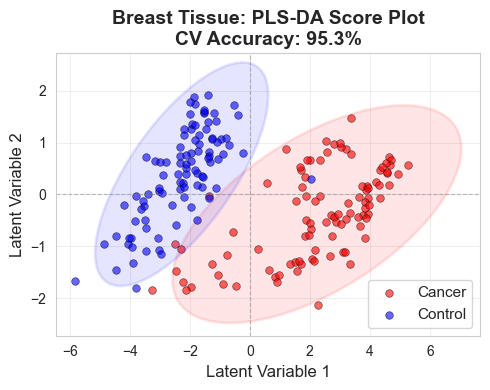

In [64]:
# PLS-DA Score plot
def plot_plsda_scores(plsda_results, title='PLS-DA Score Plot'):
    """
    Create PLS-DA score plot.
    """
    scores_df = plsda_results['scores']
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # Plot by group
    for group in ['Cancer', 'Control']:
        group_data = scores_df[scores_df['Group'] == group]
        color = 'red' if group == 'Cancer' else 'blue'
        
        ax.scatter(group_data['LV1'], group_data['LV2'], 
                   label=group, alpha=0.6, s=30, color=color, edgecolors='black', linewidth=0.5)
        
        # Add confidence ellipse
        if len(group_data) > 2:
            mean_x, mean_y = group_data['LV1'].mean(), group_data['LV2'].mean()
            cov = np.cov(group_data['LV1'], group_data['LV2'])
            lambda_, v = np.linalg.eig(cov)
            lambda_ = np.sqrt(lambda_)
            angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
            
            ellipse = Ellipse((mean_x, mean_y), 
                             width=lambda_[0]*2*2.447,
                             height=lambda_[1]*2*2.447,
                             angle=angle, 
                             facecolor=color, 
                             alpha=0.1, 
                             edgecolor=color, 
                             linewidth=2)
            ax.add_patch(ellipse)
    
    ax.set_xlabel('Latent Variable 1', fontsize=12)
    ax.set_ylabel('Latent Variable 2', fontsize=12)
    ax.set_title(f"{title}\nCV Accuracy: {plsda_results['cv_accuracy']*100:.1f}%", 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_plsda_scores(breast_plsda, title='Breast Tissue: PLS-DA Score Plot')

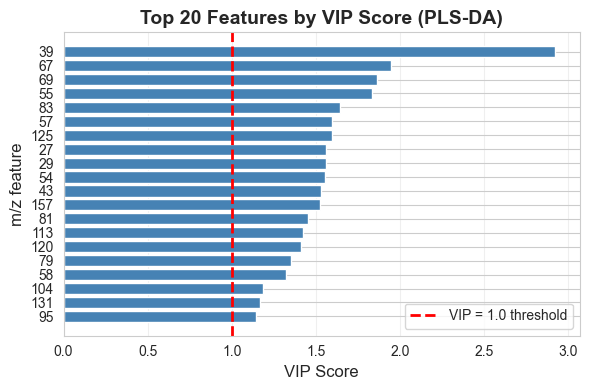


Top 10 VIP features:
   Feature       VIP
11      39  2.923527
30      67  1.943499
32      69  1.860737
22      55  1.831592
44      83  1.644179
24      57  1.594588
74     125  1.593469
5       27  1.559546
7       29  1.559147
21      54  1.553816


In [65]:
# VIP scores plot
top_vip = breast_plsda['vip'].head(20)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(range(len(top_vip)), top_vip['VIP'].values, color='steelblue')
ax.set_yticks(range(len(top_vip)))
ax.set_yticklabels(top_vip['Feature'].values)
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='VIP = 1.0 threshold')
ax.set_xlabel('VIP Score', fontsize=12)
ax.set_ylabel('m/z feature', fontsize=12)
ax.set_title('Top 20 Features by VIP Score (PLS-DA)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nTop 10 VIP features:")
print(breast_plsda['vip'].head(10))

## 3.4 ROC Curve and Classification Performance

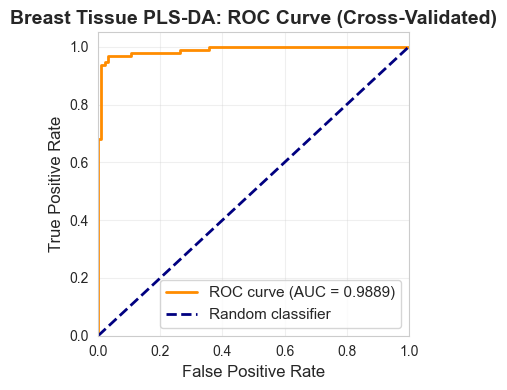


AUC-ROC: 0.9889


In [83]:
# ROC curve for PLS-DA
def plot_roc_curve(y_true, y_pred_proba, title='ROC Curve'):
    """
    Plot ROC curve and calculate AUC.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(4, 4))
    
    ax.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--', label='Random classifier')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return roc_auc

breast_auc = plot_roc_curve(
    breast_plsda['true_labels'], 
    breast_plsda['cv_predictions'],
    title='Breast Tissue PLS-DA: ROC Curve (Cross-Validated)'
)

print(f"\nAUC-ROC: {breast_auc:.4f}")

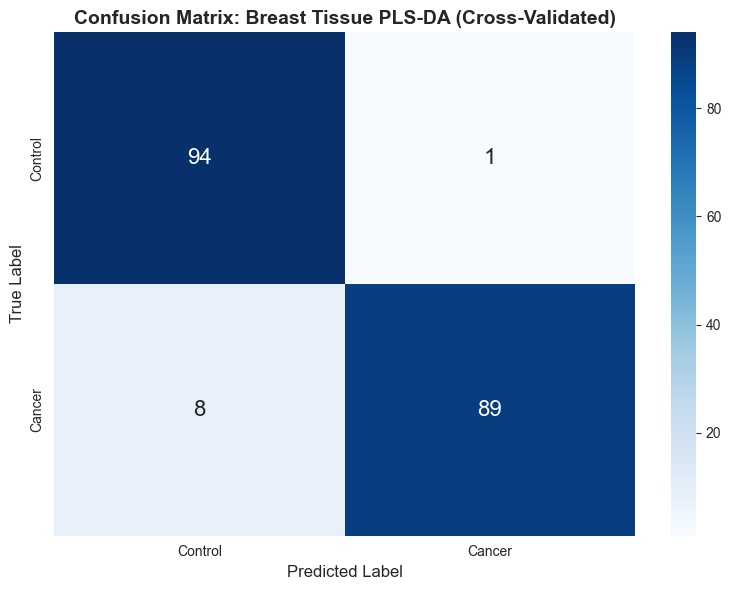


Classification Metrics:
  Accuracy: 95.31%
  Sensitivity (Recall): 91.75%
  Specificity: 98.95%
  F1-Score: 95.19%


In [67]:
# Confusion matrix
y_pred_class = (breast_plsda['cv_predictions'] > 0.5).astype(int)
cm = confusion_matrix(breast_plsda['true_labels'], y_pred_class)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Control', 'Cancer'], yticklabels=['Control', 'Cancer'],
            ax=ax, annot_kws={'size': 16})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix: Breast Tissue PLS-DA (Cross-Validated)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"\nClassification Metrics:")
print(f"  Accuracy: {accuracy*100:.2f}%")
print(f"  Sensitivity (Recall): {sensitivity*100:.2f}%")
print(f"  Specificity: {specificity*100:.2f}%")
print(f"  F1-Score: {f1_score(breast_plsda['true_labels'], y_pred_class)*100:.2f}%")

## 3.5 Random Forest Classification

In [76]:
def perform_random_forest(data, metadata, n_estimators=100, max_depth=4):
    """
    Perform Random Forest classification with CV-based feature importance.
    
    IMPORTANT: Feature importance is now calculated DURING cross-validation,
    making it comparable to PLS-DA VIP scores. This prevents data leakage
    and ensures importance reflects generalization, not overfitting.
    
    Parameters:
    -----------
    data : DataFrame
        Feature data
    metadata : DataFrame
        Sample metadata with 'Group' and 'Mouse' columns
    n_estimators : int
        Number of trees in the forest
    max_depth : int or None
        Maximum tree depth
        
    Returns:
    --------
    Dictionary with:
    - mean_importance: Average importance across CV folds
    - std_importance: Standard deviation of importance across folds
    - cv_predictions: Cross-validated predictions
    - cv_accuracy: Cross-validation accuracy
    - fold_importances: List of importance arrays from each fold
    """
    # Prepare data
    X = data.fillna(0).values
    y = (metadata['Group'] == 'Cancer').astype(int).values
    groups = metadata['Mouse'].values
    
    # Cross-validation (leave-one-mouse-out)
    logo = LeaveOneGroupOut()
    
    # Store results from each fold
    fold_importances = []
    cv_predictions = np.zeros(len(y))
    
    print(f"Random Forest with {n_estimators} trees")
    print(f"Running Leave-One-Mouse-Out CV ({len(np.unique(groups))} folds)...")
    
    # Perform CV manually to extract importance from each fold
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train model on this fold
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            oob_score=True
        )
        rf.fit(X_train, y_train)
        
        # Store feature importance from this fold
        fold_importances.append(rf.feature_importances_)
        
        # Store predictions for this fold
        cv_predictions[test_idx] = rf.predict_proba(X_test)[:, 1]
    
    # Calculate mean and std of importance across folds
    fold_importances = np.array(fold_importances)
    mean_importance = fold_importances.mean(axis=0)
    std_importance = fold_importances.std(axis=0)
    
    # Calculate CV accuracy
    cv_accuracy = accuracy_score(y, (cv_predictions > 0.5).astype(int))
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': data.columns,
        'Importance': mean_importance,
        'Importance_Std': std_importance,
        'CV_Coefficient': std_importance / (mean_importance + 1e-10)  # Stability metric
    }).sort_values('Importance', ascending=False)
    
    print(f"  CV Accuracy: {cv_accuracy*100:.2f}%")
    print(f"  Features ranked by mean CV importance")
    print(f"  Importance stability (mean CV): {importance_df['CV_Coefficient'].mean():.3f}")
    
    return {
        'importance': importance_df,
        'mean_importance': mean_importance,
        'std_importance': std_importance,
        'cv_predictions': cv_predictions,
        'cv_accuracy': cv_accuracy,
        'true_labels': y,
        'fold_importances': fold_importances
    }

# Perform Random Forest on breast tissue
print("Performing Random Forest on Breast Tissue...\n")
breast_rf = perform_random_forest(breast_data['data_processed'], breast_data['metadata'])

Performing Random Forest on Breast Tissue...

Random Forest with 100 trees
Running Leave-One-Mouse-Out CV (20 folds)...
  CV Accuracy: 96.35%
  Features ranked by mean CV importance
  Importance stability (mean CV): 0.737


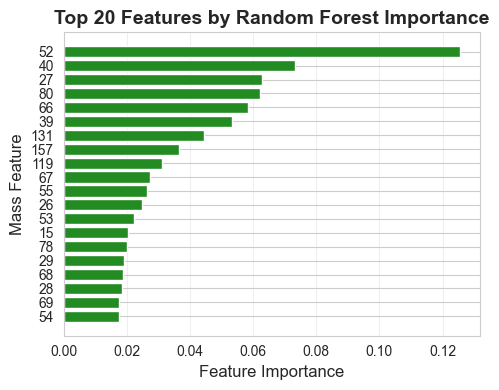


Top 10 most important features:
   Feature  Importance  Importance_Std  CV_Coefficient
19      52    0.125587        0.008128        0.064724
12      40    0.073281        0.004787        0.065326
5       27    0.062804        0.012616        0.200882
41      80    0.062169        0.016056        0.258270
29      66    0.058383        0.007920        0.135648
11      39    0.053274        0.007041        0.132161
79     131    0.044478        0.014516        0.326358
86     157    0.036640        0.012133        0.331130
70     119    0.031083        0.012296        0.395595
30      67    0.027368        0.007222        0.263875


In [77]:
# Feature importance plot
top_rf_features = breast_rf['importance'].head(20)

fig, ax = plt.subplots(figsize=(5, 4))
ax.barh(range(len(top_rf_features)), top_rf_features['Importance'].values, color='forestgreen')
ax.set_yticks(range(len(top_rf_features)))
ax.set_yticklabels(top_rf_features['Feature'].values)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_ylabel('Mass Feature', fontsize=12)
ax.set_title('Top 20 Features by Random Forest Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features:")
print(breast_rf['importance'].head(10))

In [78]:
# Alternative: Permutation Importance (most robust, but computationally expensive)
def perform_permutation_importance(data, metadata, n_repeats=100, n_estimators=100):
    """
    Calculate permutation-based feature importance.
    
    This is the most robust method as it measures the decrease in model
    performance when each feature is randomly shuffled. Works by:
    1. Train model on real data
    2. For each feature, shuffle its values and measure performance drop
    3. Average over multiple shuffles
    
    More computationally expensive but methodologically superior.
    """
    from sklearn.inspection import permutation_importance
    
    X = data.fillna(0).values
    y = (metadata['Group'] == 'Cancer').astype(int).values
    groups = metadata['Mouse'].values
    
    print(f"Calculating permutation importance ({n_repeats} repeats)...")
    print("This may take a few minutes...\n")
    
    # Train final model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X, y)
    
    # Calculate permutation importance
    perm_result = permutation_importance(
        rf, X, y,
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Create dataframe
    perm_df = pd.DataFrame({
        'Feature': data.columns,
        'Importance': perm_result.importances_mean,
        'Importance_Std': perm_result.importances_std
    }).sort_values('Importance', ascending=False)
    
    print(f"Permutation importance calculated!")
    print(f"Top 5 features by permutation importance:")
    print(perm_df.head())
    
    return {
        'importance': perm_df,
        'importances_mean': perm_result.importances_mean,
        'importances_std': perm_result.importances_std,
        'importances': perm_result.importances
    }

# Optional: Run permutation importance (comment out if too slow)
breast_perm = perform_permutation_importance(breast_data['data_processed'], breast_data['metadata'])

print("Note: Permutation importance is commented out by default due to computational cost.")
print("Uncomment the line above if you want to run it (may take 5-10 minutes).")

Calculating permutation importance (100 repeats)...
This may take a few minutes...

Permutation importance calculated!
Top 5 features by permutation importance:
   Feature    Importance  Importance_Std
17      50  2.109424e-17    4.355415e-17
81     141  1.110223e-17    3.330669e-17
23      56  9.992007e-18    3.177256e-17
5       27  7.771561e-18    2.832701e-17
42      81  7.771561e-18    2.832701e-17
Note: Permutation importance is commented out by default due to computational cost.
Uncomment the line above if you want to run it (may take 5-10 minutes).


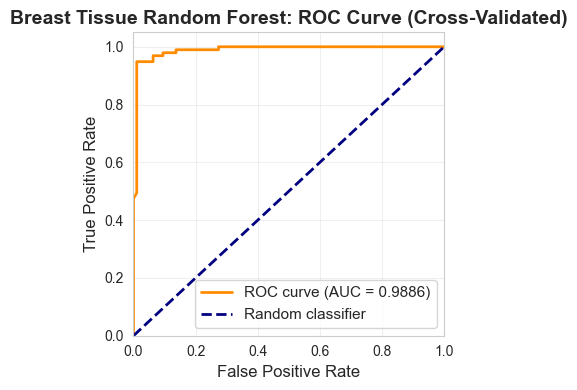


Random Forest AUC-ROC: 0.9886


In [84]:
# ROC curve for Random Forest
rf_auc = plot_roc_curve(
    breast_rf['true_labels'], 
    breast_rf['cv_predictions'],
    title='Breast Tissue Random Forest: ROC Curve (Cross-Validated)'
)

print(f"\nRandom Forest AUC-ROC: {rf_auc:.4f}")

## 3.6 Consensus Biomarker Identification

In [72]:
# Combine results from multiple methods
def identify_consensus_biomarkers(univariate_df, plsda_vip, rf_importance, 
                                   top_n=20, vip_threshold=1.0, fdr_threshold=0.05,
                                   rf_importance_percentile=80):
    """
    Identify consensus biomarkers across multiple methods.
    
    Now uses CV-based RF importance for fair comparison with PLS-DA VIP.
    
    Parameters:
    -----------
    univariate_df : DataFrame
        Univariate test results
    plsda_vip : DataFrame
        PLS-DA VIP scores
    rf_importance : DataFrame
        Random Forest importance (CV-based)
    top_n : int
        Number of top features to consider from RF
    vip_threshold : float
        Minimum VIP score
    fdr_threshold : float
        Maximum FDR for univariate
    rf_importance_percentile : float
        Percentile threshold for RF importance (default 80th percentile)
    """
    # Top features from each method
    univar_sig = univariate_df[
        (univariate_df['FDR_ttest'] < fdr_threshold) & 
        (abs(univariate_df['Cohens_d']) > 0.5)
    ]['Feature'].tolist()
    
    vip_sig = plsda_vip[plsda_vip['VIP'] > vip_threshold]['Feature'].tolist()
    
    # For RF, use percentile-based threshold (more robust than fixed top_n)
    rf_threshold = np.percentile(rf_importance['Importance'], rf_importance_percentile)
    rf_sig = rf_importance[rf_importance['Importance'] >= rf_threshold]['Feature'].tolist()
    
    # Alternative: just use top_n
    # rf_sig = rf_importance.head(top_n)['Feature'].tolist()
    
    # Find consensus
    all_features = set(univar_sig + vip_sig + rf_sig)
    consensus_scores = {}
    
    for feature in all_features:
        score = 0
        if feature in univar_sig:
            score += 1
        if feature in vip_sig:
            score += 1
        if feature in rf_sig:
            score += 1
        consensus_scores[feature] = score
    
    # Create consensus dataframe
    consensus_df = pd.DataFrame([
        {'Feature': feat, 'Consensus_Score': score, 
         'In_Univariate': feat in univar_sig,
         'In_VIP': feat in vip_sig,
         'In_RF': feat in rf_sig}
        for feat, score in consensus_scores.items()
    ]).sort_values('Consensus_Score', ascending=False)
    
    # Add statistics
    consensus_df = consensus_df.merge(
        univariate_df[['Feature', 'Log2_FC', 'Cohens_d', 'FDR_ttest']],
        on='Feature', how='left'
    )
    
    consensus_df = consensus_df.merge(
        plsda_vip[['Feature', 'VIP']],
        on='Feature', how='left'
    )
    
    consensus_df = consensus_df.merge(
        rf_importance[['Feature', 'Importance', 'Importance_Std']],
        on='Feature', how='left'
    )
    
    print(f"\nConsensus Biomarker Summary:")
    print(f"  Univariate significant: {len(univar_sig)}")
    print(f"  VIP > {vip_threshold}: {len(vip_sig)}")
    print(f"  RF importance > {rf_importance_percentile}th percentile: {len(rf_sig)}")
    print(f"  \nConsensus scores:")
    print(f"    All 3 methods: {(consensus_df['Consensus_Score'] == 3).sum()}")
    print(f"    2 methods: {(consensus_df['Consensus_Score'] == 2).sum()}")
    print(f"    1 method: {(consensus_df['Consensus_Score'] == 1).sum()}")
    
    return consensus_df

# Identify consensus biomarkers for breast tissue
breast_consensus = identify_consensus_biomarkers(
    breast_univariate,
    breast_plsda['vip'],
    breast_rf['importance']
)

print("\nTop 15 Consensus Biomarkers:")
display_cols = ['Feature', 'Consensus_Score', 'Log2_FC', 'Cohens_d', 'VIP', 'Importance']
print(breast_consensus.head(15)[display_cols].round(3))


Consensus Biomarker Summary:
  Univariate significant: 75
  VIP > 1.0: 31
  RF importance > 80th percentile: 19
  
Consensus scores:
    All 3 methods: 11
    2 methods: 26
    1 method: 40

Top 15 Consensus Biomarkers:
   Feature  Consensus_Score  Log2_FC  Cohens_d    VIP  Importance
0       55                3   -0.710    -1.963  1.832       0.027
1       53                3   -0.408    -2.395  1.092       0.022
2       29                3   -0.593    -2.589  1.559       0.019
3       80                3   -0.906    -2.171  1.140       0.062
4       67                3   -0.977    -2.417  1.943       0.027
5       68                3   -0.660    -1.784  1.022       0.019
6      157                3    2.656     1.589  1.523       0.036
7       69                3   -0.902    -1.860  1.861       0.017
8      131                3    0.679     2.273  1.167       0.044
9       27                3   -0.531    -2.650  1.560       0.062
10      39                3    1.675     2.976  2.924

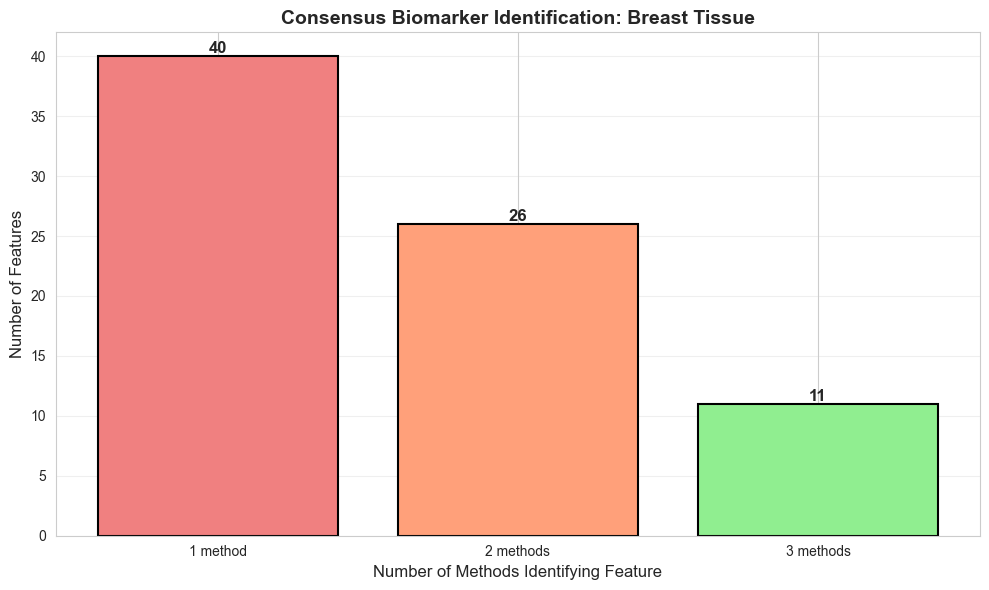

In [73]:
# Visualize consensus with Venn diagram-style plot
fig, ax = plt.subplots(figsize=(10, 6))

consensus_counts = breast_consensus['Consensus_Score'].value_counts().sort_index()
colors = ['lightcoral', 'lightsalmon', 'lightgreen']

bars = ax.bar(consensus_counts.index, consensus_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Number of Methods Identifying Feature', fontsize=12)
ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('Consensus Biomarker Identification: Breast Tissue', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['1 method', '2 methods', '3 methods'])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

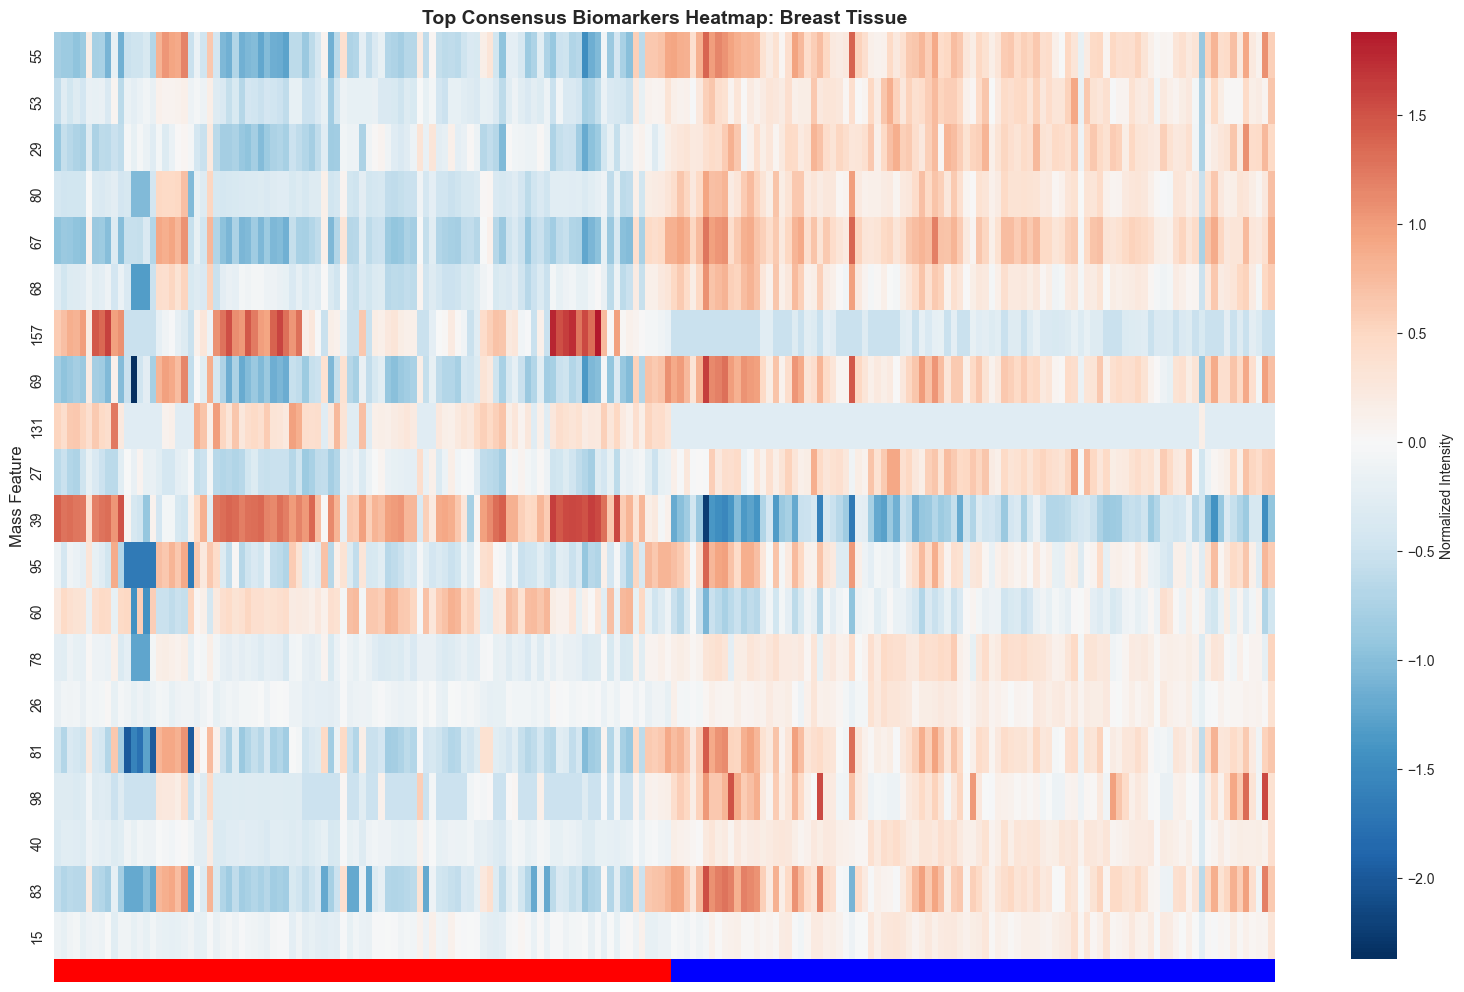

In [74]:
# Heatmap of top consensus biomarkers
top_consensus = breast_consensus[breast_consensus['Consensus_Score'] >= 2].head(20)['Feature'].tolist()

if len(top_consensus) > 0:
    # Prepare data for heatmap
    heatmap_data = breast_data['data_processed'][top_consensus].T
    
    # Sort samples by group
    sample_order = breast_data['metadata'].sort_values('Group').index
    heatmap_data = heatmap_data[sample_order]
    
    # Create group color bar
    group_colors = breast_data['metadata'].loc[sample_order, 'Group'].map(
        {'Cancer': 'red', 'Control': 'blue'}
    )
    
    # Plot
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(
        heatmap_data,
        cmap='RdBu_r',
        center=0,
        cbar_kws={'label': 'Normalized Intensity'},
        xticklabels=False,
        yticklabels=top_consensus,
        ax=ax
    )
    
    ax.set_xlabel('Samples (sorted by group)', fontsize=12)
    ax.set_ylabel('Mass Feature', fontsize=12)
    ax.set_title('Top Consensus Biomarkers Heatmap: Breast Tissue', fontsize=14, fontweight='bold')
    
    # Add group color bar at top
    for i, color in enumerate(group_colors):
        ax.add_patch(plt.Rectangle((i, len(top_consensus)), 1, 0.5, 
                                    facecolor=color, edgecolor='none', 
                                    transform=ax.transData, clip_on=False))
    
    plt.tight_layout()
    plt.show()
else:
    print("No features with consensus score >= 2 found.")

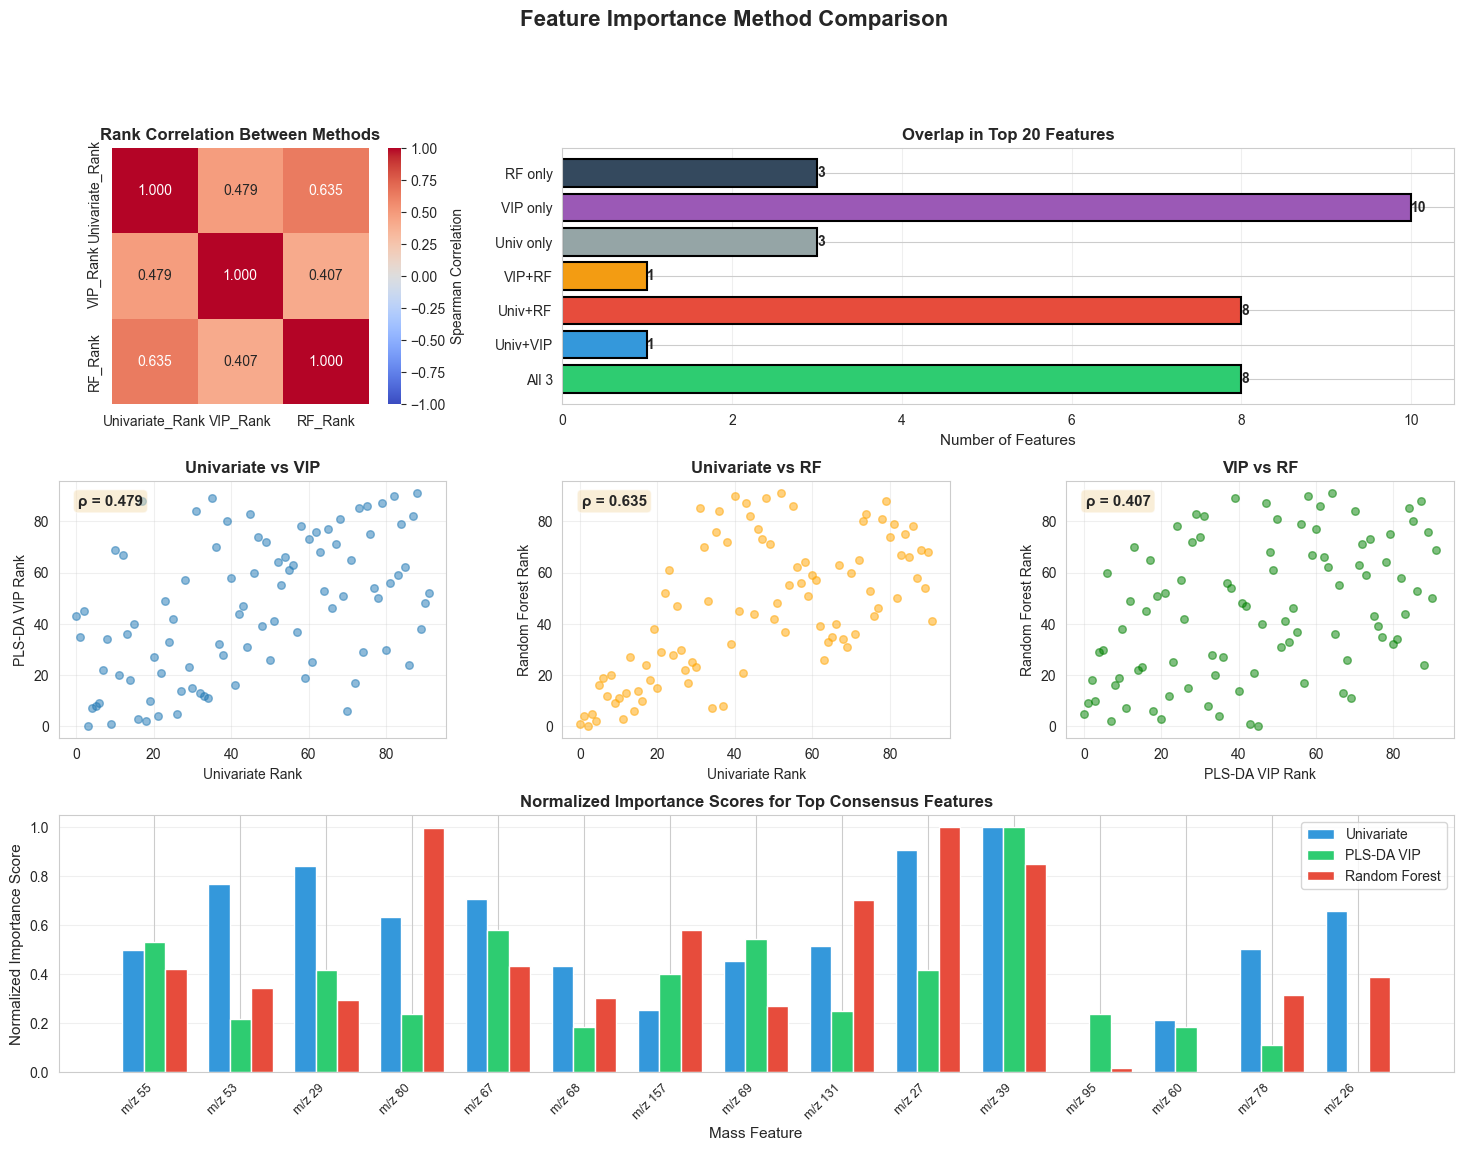

In [75]:
# Compare feature importance rankings across methods
def plot_method_comparison(univariate_df, plsda_vip, rf_importance, top_n=20):
    """
    Visualize agreement between different feature importance methods.
    """
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Rank correlation heatmap
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Get common features
    common_features = set(univariate_df['Feature']) & set(plsda_vip['Feature']) & set(rf_importance['Feature'])
    
    # Create ranking dataframe
    rank_df = pd.DataFrame({'Feature': list(common_features)})
    
    # Add ranks from each method
    univar_ranks = univariate_df.reset_index(drop=True).reset_index().rename(columns={'index': 'Univariate_Rank'})
    vip_ranks = plsda_vip.reset_index(drop=True).reset_index().rename(columns={'index': 'VIP_Rank'})
    rf_ranks = rf_importance.reset_index(drop=True).reset_index().rename(columns={'index': 'RF_Rank'})
    
    rank_df = rank_df.merge(univar_ranks[['Feature', 'Univariate_Rank']], on='Feature')
    rank_df = rank_df.merge(vip_ranks[['Feature', 'VIP_Rank']], on='Feature')
    rank_df = rank_df.merge(rf_ranks[['Feature', 'RF_Rank']], on='Feature')
    
    # Calculate correlation
    corr_matrix = rank_df[['Univariate_Rank', 'VIP_Rank', 'RF_Rank']].corr(method='spearman')
    
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, square=True, ax=ax1,
                cbar_kws={'label': 'Spearman Correlation'})
    ax1.set_title('Rank Correlation Between Methods', fontweight='bold', fontsize=12)
    
    # 2. Top features Venn-style comparison
    ax2 = fig.add_subplot(gs[0, 1:])
    
    top_univar = set(univariate_df.head(top_n)['Feature'])
    top_vip = set(plsda_vip.head(top_n)['Feature'])
    top_rf = set(rf_importance.head(top_n)['Feature'])
    
    overlap_data = [
        len(top_univar & top_vip & top_rf),  # All 3
        len((top_univar & top_vip) - top_rf),  # Univar + VIP only
        len((top_univar & top_rf) - top_vip),  # Univar + RF only
        len((top_vip & top_rf) - top_univar),  # VIP + RF only
        len(top_univar - top_vip - top_rf),  # Univar only
        len(top_vip - top_univar - top_rf),  # VIP only
        len(top_rf - top_univar - top_vip)   # RF only
    ]
    
    labels = ['All 3', 'Univ+VIP', 'Univ+RF', 'VIP+RF', 'Univ only', 'VIP only', 'RF only']
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#95a5a6', '#9b59b6', '#34495e']
    
    bars = ax2.barh(labels, overlap_data, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Number of Features', fontsize=11)
    ax2.set_title(f'Overlap in Top {top_n} Features', fontweight='bold', fontsize=12)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        if width > 0:
            ax2.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)}',
                    ha='left', va='center', fontweight='bold', fontsize=10)
    
    # 3-5. Scatter plots comparing rankings
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[1, 2])
    
    # Univariate vs VIP
    scatter_df = rank_df.copy()
    ax3.scatter(scatter_df['Univariate_Rank'], scatter_df['VIP_Rank'], alpha=0.5, s=30)
    ax3.set_xlabel('Univariate Rank', fontsize=10)
    ax3.set_ylabel('PLS-DA VIP Rank', fontsize=10)
    ax3.set_title('Univariate vs VIP', fontweight='bold')
    ax3.grid(alpha=0.3)
    
    # Add correlation text
    r_val = corr_matrix.loc['Univariate_Rank', 'VIP_Rank']
    ax3.text(0.05, 0.95, f'ρ = {r_val:.3f}', transform=ax3.transAxes,
            fontsize=11, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Univariate vs RF
    ax4.scatter(scatter_df['Univariate_Rank'], scatter_df['RF_Rank'], alpha=0.5, s=30, color='orange')
    ax4.set_xlabel('Univariate Rank', fontsize=10)
    ax4.set_ylabel('Random Forest Rank', fontsize=10)
    ax4.set_title('Univariate vs RF', fontweight='bold')
    ax4.grid(alpha=0.3)
    
    r_val = corr_matrix.loc['Univariate_Rank', 'RF_Rank']
    ax4.text(0.05, 0.95, f'ρ = {r_val:.3f}', transform=ax4.transAxes,
            fontsize=11, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # VIP vs RF
    ax5.scatter(scatter_df['VIP_Rank'], scatter_df['RF_Rank'], alpha=0.5, s=30, color='green')
    ax5.set_xlabel('PLS-DA VIP Rank', fontsize=10)
    ax5.set_ylabel('Random Forest Rank', fontsize=10)
    ax5.set_title('VIP vs RF', fontweight='bold')
    ax5.grid(alpha=0.3)
    
    r_val = corr_matrix.loc['VIP_Rank', 'RF_Rank']
    ax5.text(0.05, 0.95, f'ρ = {r_val:.3f}', transform=ax5.transAxes,
            fontsize=11, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 6. Normalized importance comparison for top features
    ax6 = fig.add_subplot(gs[2, :])
    
    # Get top consensus features
    top_features = breast_consensus.head(15)['Feature'].tolist()
    
    # Normalize importance scores to 0-1 for comparison
    def normalize(series):
        return (series - series.min()) / (series.max() - series.min())
    
    comparison_data = pd.DataFrame({'Feature': top_features})
    
    # Add normalized scores
    for feat in top_features:
        # Univariate (use -log10(p-value))
        pval = univariate_df[univariate_df['Feature'] == feat]['T_test_pval'].values[0]
        comparison_data.loc[comparison_data['Feature'] == feat, 'Univariate'] = -np.log10(pval)
        
        # VIP
        vip = plsda_vip[plsda_vip['Feature'] == feat]['VIP'].values
        comparison_data.loc[comparison_data['Feature'] == feat, 'VIP'] = vip[0] if len(vip) > 0 else 0
        
        # RF
        rf_imp = rf_importance[rf_importance['Feature'] == feat]['Importance'].values
        comparison_data.loc[comparison_data['Feature'] == feat, 'RF'] = rf_imp[0] if len(rf_imp) > 0 else 0
    
    # Normalize each method
    comparison_data['Univariate_norm'] = normalize(comparison_data['Univariate'])
    comparison_data['VIP_norm'] = normalize(comparison_data['VIP'])
    comparison_data['RF_norm'] = normalize(comparison_data['RF'])
    
    # Plot grouped bars
    x = np.arange(len(top_features))
    width = 0.25
    
    ax6.bar(x - width, comparison_data['Univariate_norm'], width, label='Univariate', color='#3498db')
    ax6.bar(x, comparison_data['VIP_norm'], width, label='PLS-DA VIP', color='#2ecc71')
    ax6.bar(x + width, comparison_data['RF_norm'], width, label='Random Forest', color='#e74c3c')
    
    ax6.set_xlabel('Mass Feature', fontsize=11)
    ax6.set_ylabel('Normalized Importance Score', fontsize=11)
    ax6.set_title('Normalized Importance Scores for Top Consensus Features', fontweight='bold', fontsize=12)
    ax6.set_xticks(x)
    ax6.set_xticklabels([f"m/z {f}" for f in top_features], rotation=45, ha='right', fontsize=9)
    ax6.legend(fontsize=10)
    ax6.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Feature Importance Method Comparison', fontsize=16, fontweight='bold', y=0.995)
    plt.show()

# Generate comparison plot
plot_method_comparison(breast_univariate, breast_plsda['vip'], breast_rf['importance'])